In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal, init_to_median
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gc
import os


# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from utils.data_generator import DataGenerator
from utils.methods_2 import evaluate_metrics
from utils.recursive_inference import recursive_inference
from utils.zoomed_plots import zoomed_plots

# Real data

We now apply the ESN architecture with Stochastic Variational Inference to real data. Specifically, we consider two time series of brain signals, each composed of 119 regions and 1200 time steps. The first dataset is used for training and validation, while the second is used for testing.

In [2]:
# Load the MAT file for training and validation
mat_file = sio.loadmat('./real_data/100307.REST1.LR.SchaeferS.ptseries.mat')
data = torch.from_numpy(mat_file['tseries']).float()

In [3]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

## Random search

We now want to try to optimize the architecture by tuning the hyperparameters of the system, in particular we vary:
- Spectral radius of $W$
- Number of neurons
- Reservoir's activation function
- Adam's learning rate
- Sampled weights variance

In [4]:
# parameters space
spectral_radius_list = [0.3,0.5,0.7,0.9]
neurons_list = [16, 32, 64, 128, 256]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]
INPUT_DIM = data.shape[0]

# ranges for each region (used to normalize the mcrps)

ranges = data.max(dim=1).values - data.min(dim=1).values
      

In [ ]:
num_iterations = 100
results = []

for i in range(num_iterations):
    # Clear Pyro's parameter store to prevent memory leaks across trials
    pyro.clear_param_store()
    
    # Sample hyperparameters randomly for this trial
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    spectral_radius = random.choice(spectral_radius_list)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}, Spectral radius={spectral_radius}")

    try:
        # Setup Optimizer and Pyro Guide
        optimizer = pyro.optim.Adam({"lr": lr})
        
        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # Instantiate the Bayesian ESN model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=spectral_radius,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # Construct dataset and DataLoader for this specific reservoir state
        train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7)
        current_train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)

        # Train the model
        esn_var.train(current_train_loader, epochs=100)

        # Disable gradient tracking to save massive amounts of RAM during inference
        with torch.no_grad():
            scaler = {'mean': train_ds.mean, 'std': train_ds.std}
            
            # Get predictions
            y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, valid_ds, scaler = scaler, plot=False, num_samples = 1000)
            
            # Detach tensors from the computational graph to ensure they don't hold memory
            if isinstance(y_true_eval, torch.Tensor):
                y_true_eval = y_true_eval.detach()
            if isinstance(y_samples_eval, torch.Tensor):
                y_samples_eval = y_samples_eval.detach()
            
            # Calculate metrics
            ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

            ecov = ecov.mean().item()
            cal = cal.mean().item()

            # Convert the vector of mCRPS into a normalized average
            n_mcrps = mcrps / ranges
            avg_mcrps = n_mcrps.mean().item()

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'spectral_radius': spectral_radius,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'avg_mcrps': avg_mcrps
        })

        # Delete heavy objects created in this iteration
        del esn_var
        del guide
        del optimizer
        del train_ds
        del valid_ds
        del current_train_loader
        del y_true_eval
        del y_samples_eval
        del scaler
        
        # Force Python's Garbage Collector to free the unreferenced memory immediately
        gc.collect()
        
    except Exception as e:
        print(f"Error at iteration {i+1}: {e}")
        # Ensure cleanup even if an error occurs to prevent cascading Out-Of-Memory errors
        gc.collect()

In [ ]:
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['avg_mcrps', 'ecov_dist', 'cal'])

print(best_models.head(5))


    neurons activation     lr  spectral_radius  scale      ecov       cal  \
25       64     Tanh()  0.001              0.7   0.10  0.836415  0.007916   
12       64     Tanh()  0.001              0.9   0.10  0.806552  0.012093   
98       64     Tanh()  0.001              0.5   0.10  0.693825  0.034870   
18       64     ReLU()  0.010              0.3   0.01  0.958008  0.014215   
74       64     Tanh()  0.001              0.7   0.10  0.721106  0.028022   

    avg_mcrps  ecov_dist  
25   0.077760   0.113585  
12   0.077787   0.143448  
98   0.080888   0.256175  
18   0.080930   0.008008  
74   0.080976   0.228894  


## Best model

In [ ]:
best_params = best_models.iloc[0,:]
best_params

neurons                  64
activation           Tanh()
lr                    0.001
spectral_radius         0.7
scale                   0.1
ecov               0.836415
cal                0.007916
avg_mcrps           0.07776
ecov_dist          0.113585
Name: 25, dtype: object

In [ ]:
# save best parameters
os.makedirs("./best_parameters_SVI", exist_ok=True)
df_save = best_params.reset_index()
df_save.columns = ['parameter', 'value']
df_save.to_csv("./best_parameters_SVI/best_parameters_synth.csv", index=False)

## Load best model

In [5]:
# decomment if reading from file:
best_params = pd.read_csv("./best_parameters_SVI/best_parameters.csv")

In [6]:
pyro.clear_param_store()

In [7]:
best_params = best_params.set_index('parameter')['value']

In [8]:
# PARAMETERS

N_NEURONS = int(best_params['neurons'])
INPUT_DIM = data.shape[0] # equals to output dim

LR = float(best_params['lr'])
act_name = nn.Tanh() if best_params['activation'] == 'Tanh()' else nn.ReLU()
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [9]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [10]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [11]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius = float(best_params['spectral_radius']),
    scale = float(best_params['scale'])
)


In [12]:
esn_var.reservoir.activation = act_name

In [13]:
train_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

In [14]:
# retrain on the full first dataset
history = esn_var.train(train_loader, EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:06<10:32,  6.39s/it, Loss=1427.4588]

Epoch 0 | Total ELBO Loss: 1427.4588


Training Pyro ESN: 100%|██████████| 100/100 [01:13<00:00,  1.35it/s, Loss=673.0390]


In [15]:
# fetch test dataset
data_test = torch.from_numpy(sio.loadmat('./real_data/100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

In [16]:
# Generate Torch datasets
test_ds, _ = construct_dataset(esn_var.reservoir, data_test.T, train_split=1.0, burnin=0)

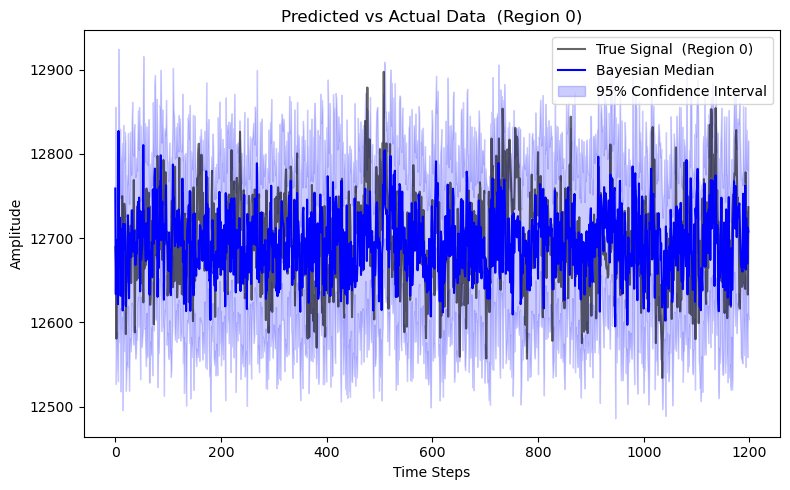

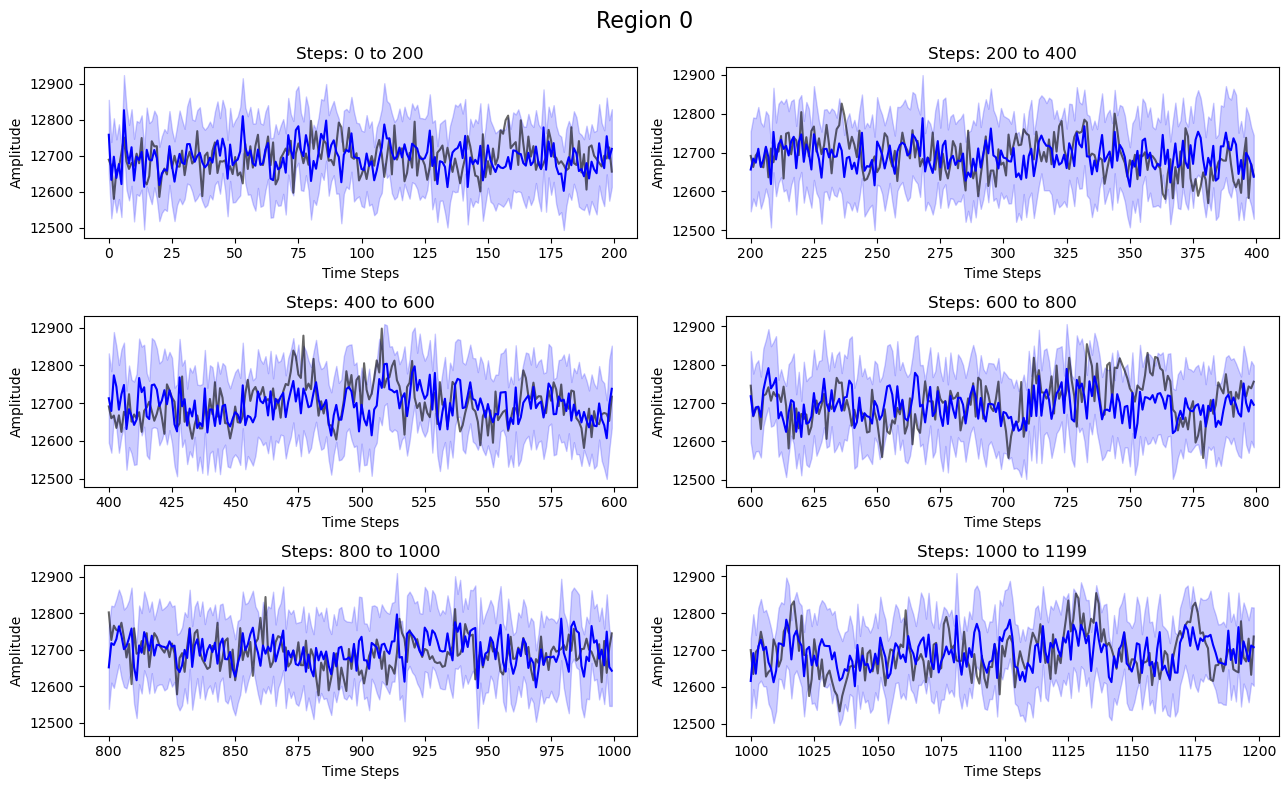

In [17]:
# predict and plot predictions for different regions
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000)
zoomed_plots(0,y_mean,y_true,upper,lower,steps = 200, n_plots=6, rows=3)

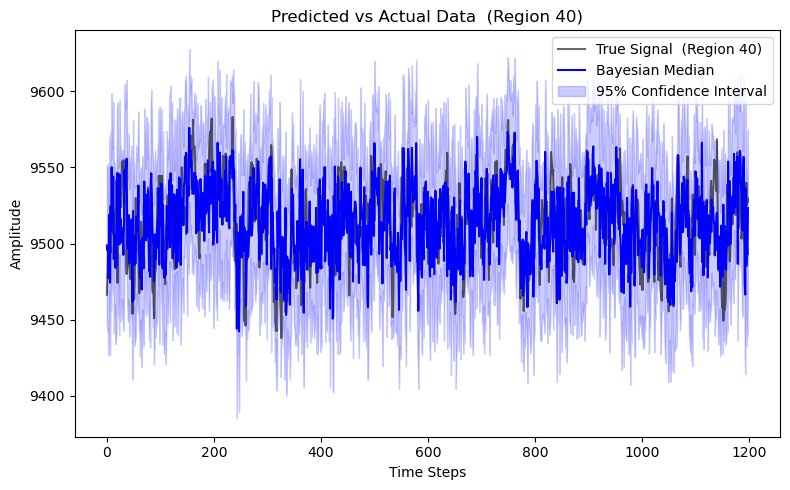

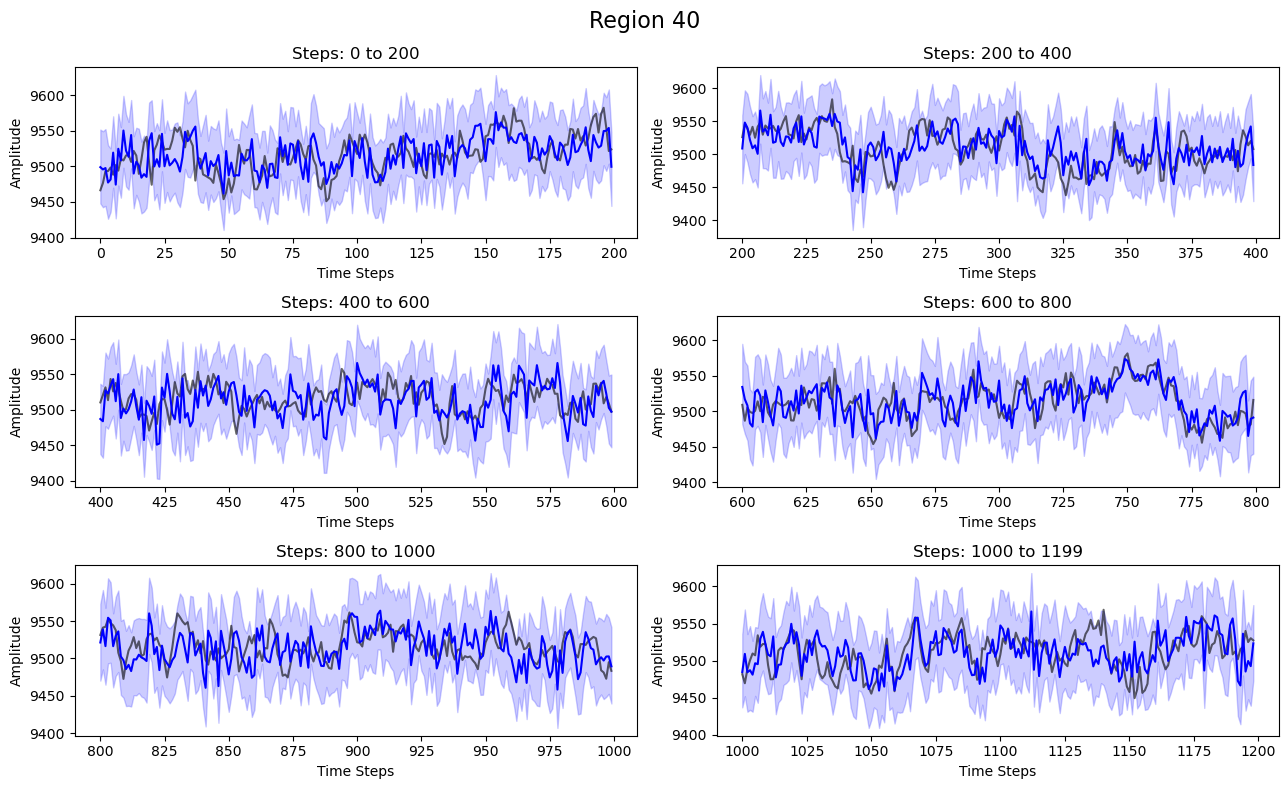

In [18]:
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000, region_idx = 40)
zoomed_plots(40, y_mean, y_true, upper,lower,steps = 200, n_plots=6, rows=3)

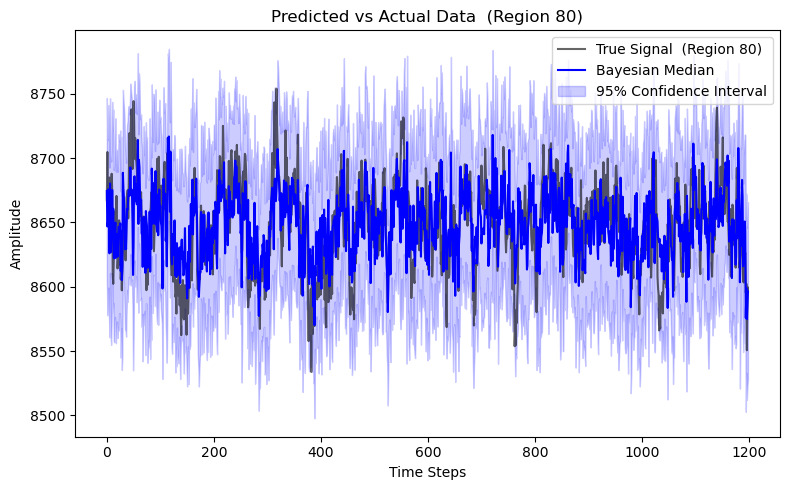

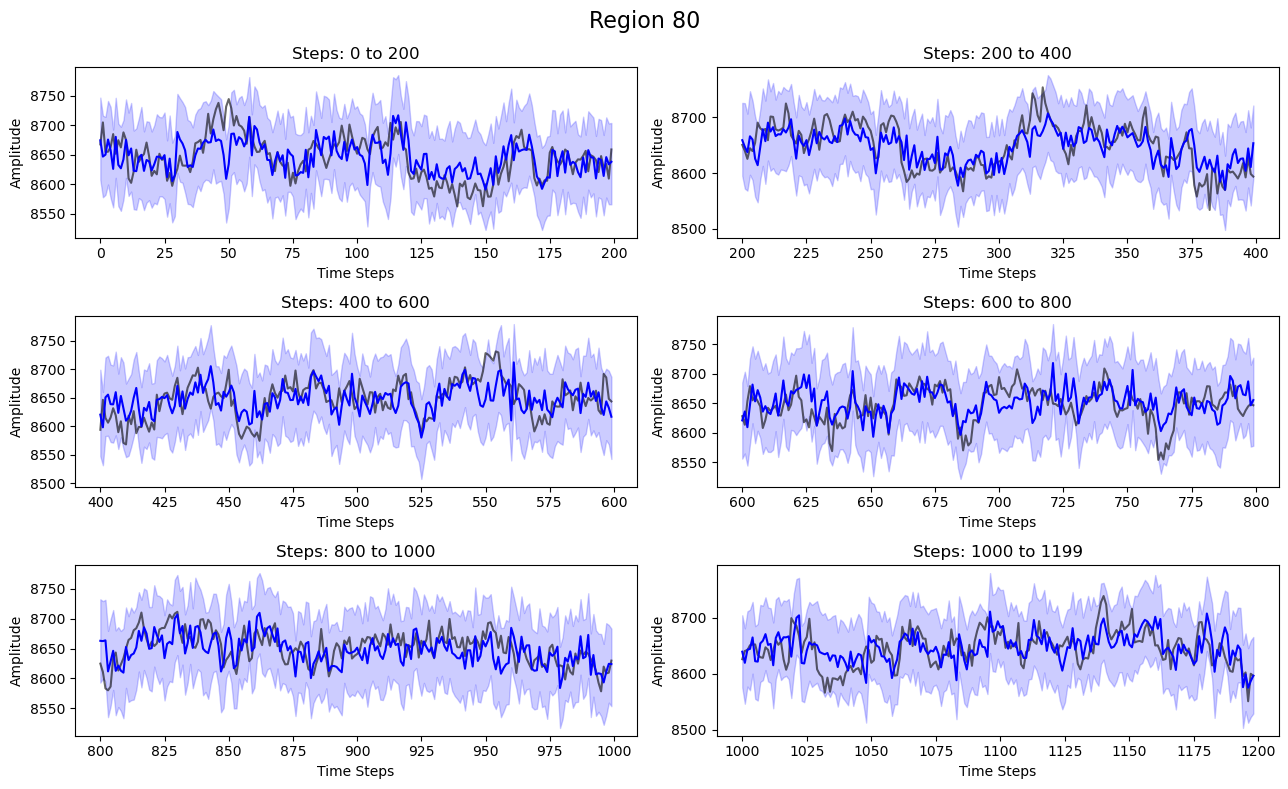

In [19]:
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000, region_idx = 80)
zoomed_plots(80,y_mean,y_true,upper,lower,steps = 200, n_plots=6, rows=3)

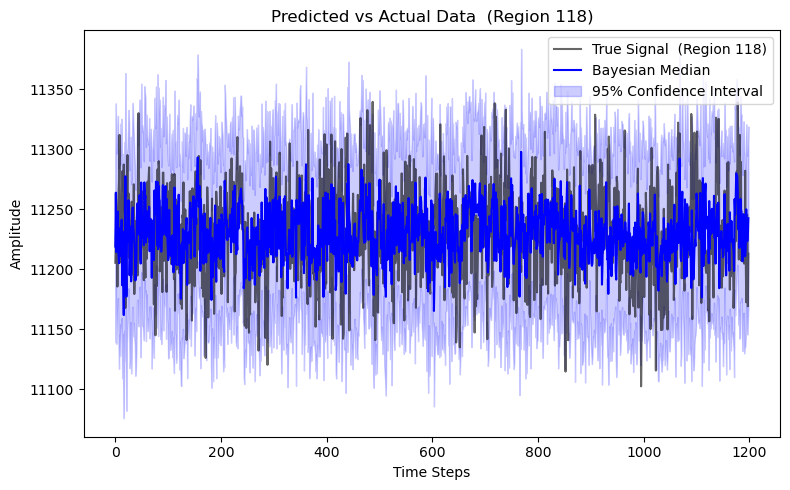

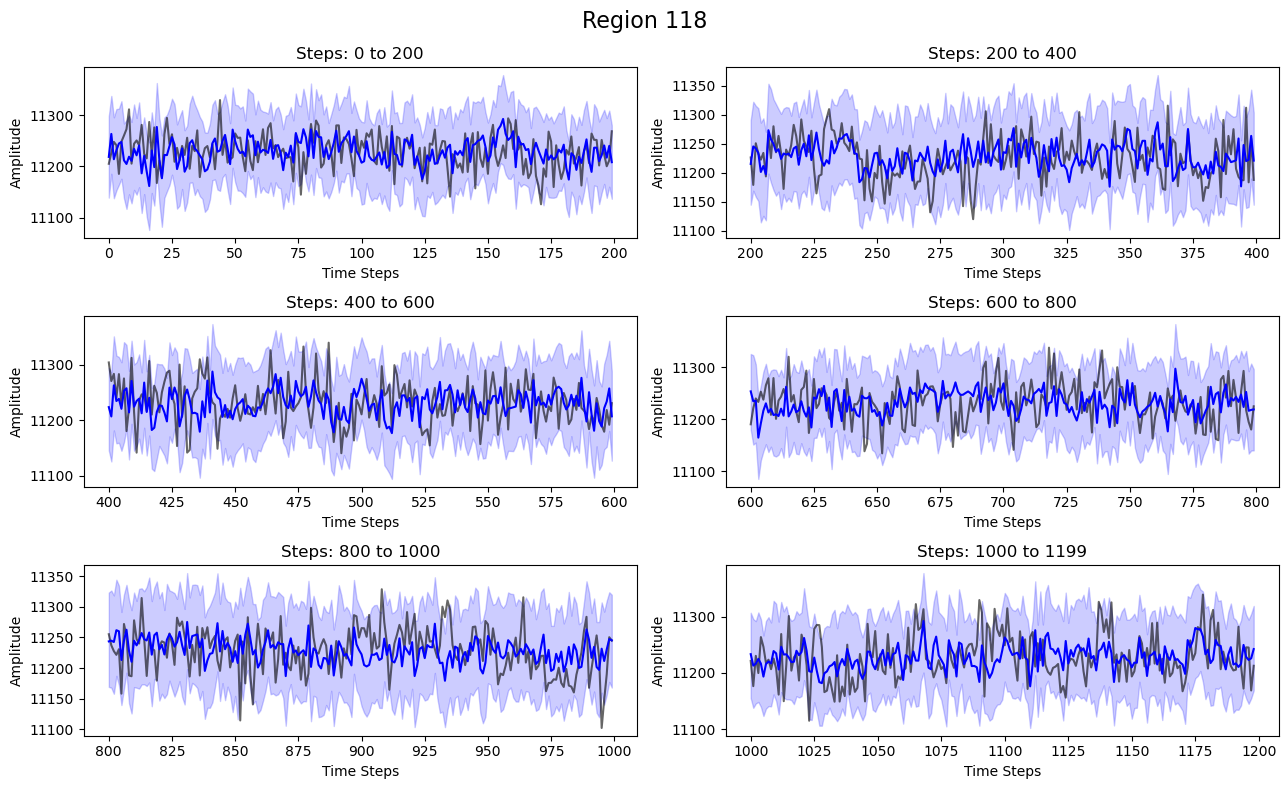

In [20]:
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000, region_idx=118)
zoomed_plots(118,y_mean,y_true,upper,lower,steps = 200, n_plots=6, rows=3)

In [21]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized average
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [22]:
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")

Empirical Coverage: 0.943 ± 0.002
Calibration Error:  0.00046 ± 0.00006
mCRPS (Normalized): 0.0890 ± 0.0010


## Visualizations

### heatmap predictions (scaled)

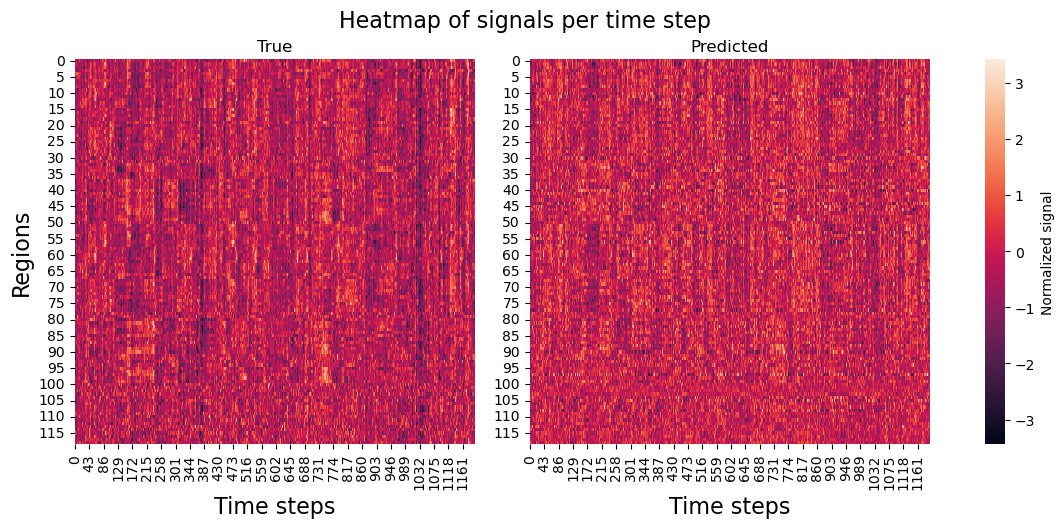

In [23]:
fig, ax = plt.subplots(1,3, figsize = (12,5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle('Heatmap of signals per time step', fontsize = 16)

m = test_ds.mean.numpy()
s = test_ds.std.numpy()

y_true_scaled = ((y_true - m) / s).T
y_mean_scaled = ((y_mean - m) / s).T


ax[0].set_title('True')
# Set the labels
sns.heatmap(y_true_scaled, cbar=False, ax=ax[0])
ax[0].set_xlabel("Time steps", fontsize=16)
ax[0].set_ylabel("Regions", fontsize=16)



sns.heatmap(y_mean_scaled, cbar_kws={'label': 'Normalized signal'}, ax=ax[1], cbar_ax=ax[2])

# Set the labels
ax[1].set_title('Predicted')
ax[1].set_xlabel("Time steps", fontsize=16)
#ax[1].set_ylabel("Regions", fontsize=16)

plt.show()


## heatmap mCRPS

In [24]:
num_samples = y_samples.shape[0]
    
# quantiles grid
tau_grid = torch.linspace(0.0, 1.0, 101)


# shape: [101, Time, Regions]
q = torch.quantile(y_samples, tau_grid, dim=0)


# y_true_extended has shape [1, Time, Regions] for broadcasting
y_true_extended = y_true.unsqueeze(0)
errors = y_true_extended - q  # [101, Time, Regions]

# Pinball Loss
# tau_grid_extended has shape [101, 1, 1] --> done for broadcasting
tau_grid_extended = tau_grid.view(-1, 1, 1)
loss = torch.max(tau_grid_extended * errors, (tau_grid_extended - 1) * errors)

In [25]:
data_heatmap = loss.mean(dim=0).T
ranges_extended = ranges.repeat(data_heatmap.shape[1],1).T
data_heatmap = (data_heatmap/ranges_extended) * 100

Text(170.72222222222223, 0.5, 'Regions')

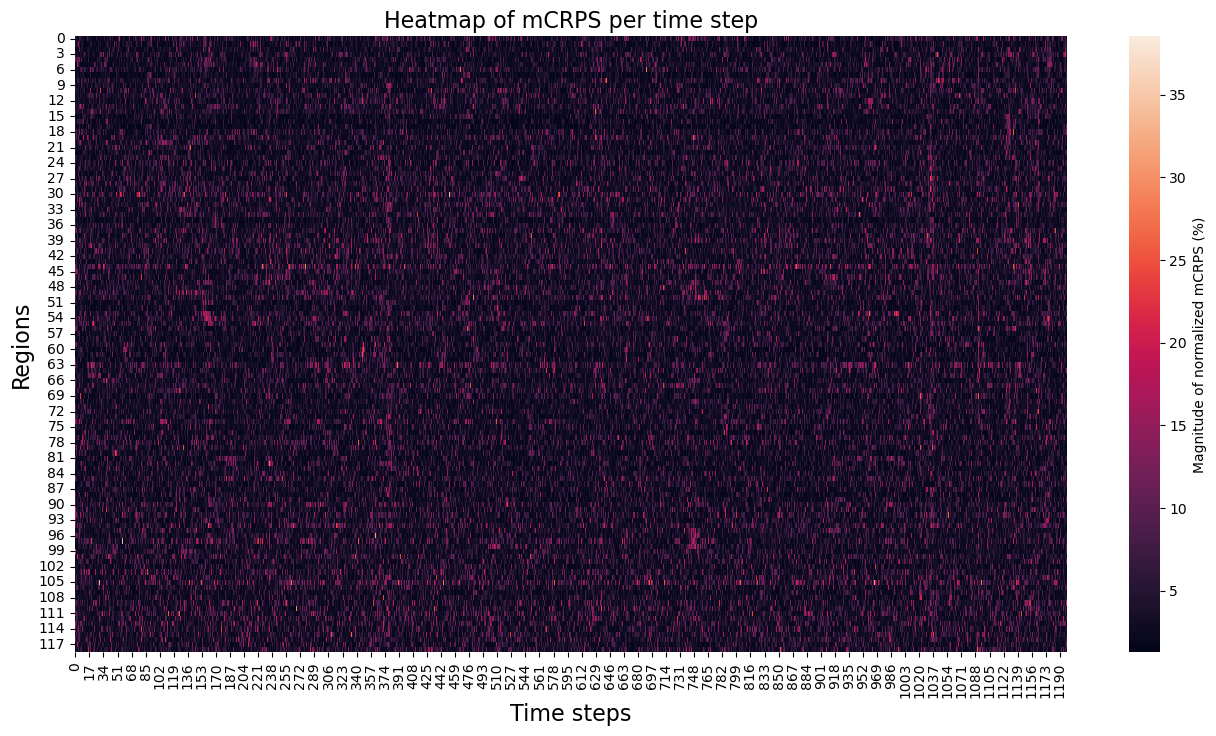

In [26]:
plt.figure(figsize=(16,8))
plt.title('Heatmap of mCRPS per time step', fontsize = 16)

ax = sns.heatmap(data_heatmap, cbar_kws={'label': 'Magnitude of normalized mCRPS (%)'})
ax.set_xlabel("Time steps", fontsize=16)
ax.set_ylabel("Regions", fontsize=16)

## Recursive forecasting

In [32]:
# 1. Run the inference
y_rec_rescaled, y_upper, y_lower, y_samples = recursive_inference(esn_var, test_ds, start_at_step=0, total_steps=None)


Step 0
Step 10
Step 20
Step 30
Step 40
Step 50
Step 60
Step 70
Step 80
Step 90
Step 100
Step 110
Step 120
Step 130
Step 140
Step 150
Step 160
Step 170
Step 180
Step 190
Step 200
Step 210
Step 220
Step 230
Step 240
Step 250
Step 260
Step 270
Step 280
Step 290
Step 300
Step 310
Step 320
Step 330
Step 340
Step 350
Step 360
Step 370
Step 380
Step 390
Step 400
Step 410
Step 420
Step 430
Step 440
Step 450
Step 460
Step 470
Step 480
Step 490
Step 500
Step 510
Step 520
Step 530
Step 540
Step 550
Step 560
Step 570
Step 580
Step 590
Step 600
Step 610
Step 620
Step 630
Step 640
Step 650
Step 660
Step 670
Step 680
Step 690
Step 700
Step 710
Step 720
Step 730
Step 740
Step 750
Step 760
Step 770
Step 780
Step 790
Step 800
Step 810
Step 820
Step 830
Step 840
Step 850
Step 860
Step 870
Step 880
Step 890
Step 900
Step 910
Step 920
Step 930
Step 940
Step 950
Step 960
Step 970
Step 980
Step 990
Step 1000
Step 1010
Step 1020
Step 1030
Step 1040
Step 1050
Step 1060
Step 1070
Step 1080
Step 1090
Step 1100
S

In [33]:
# Un-scale
y_true_abs = (test_ds.predictions * test_ds.std) + test_ds.mean
y_pred_abs = (y_rec_rescaled * test_ds.std) + test_ds.mean
y_samples_scaled = (y_samples * test_ds.std) + test_ds.mean
y_upper_scaled = (y_upper * test_ds.std) + test_ds.mean
y_lower_scaled = (y_lower * test_ds.std) + test_ds.mean

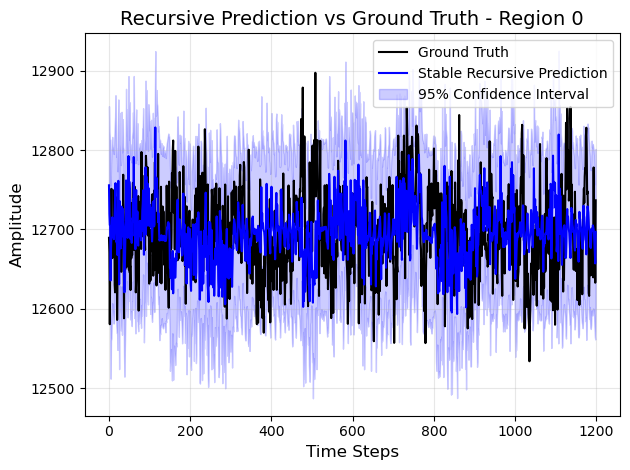

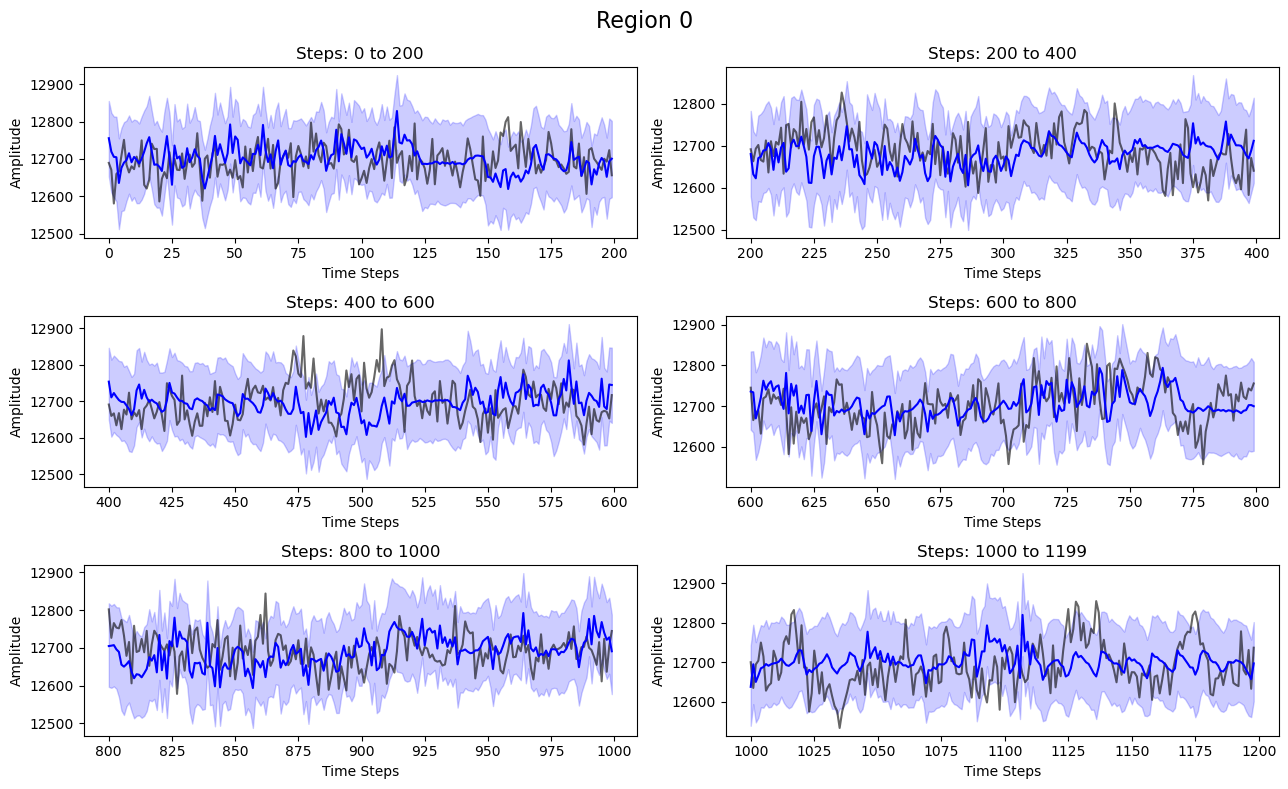

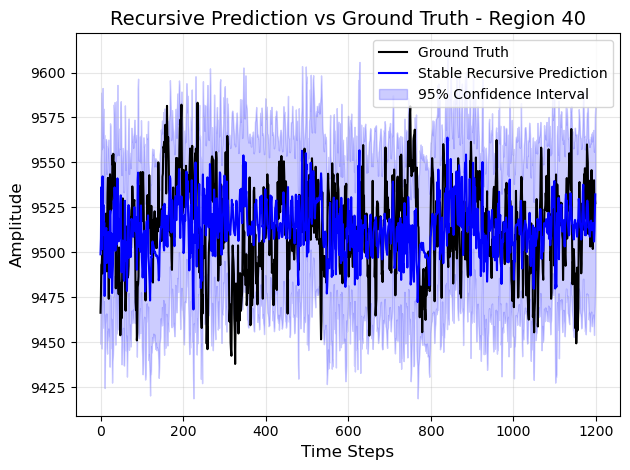

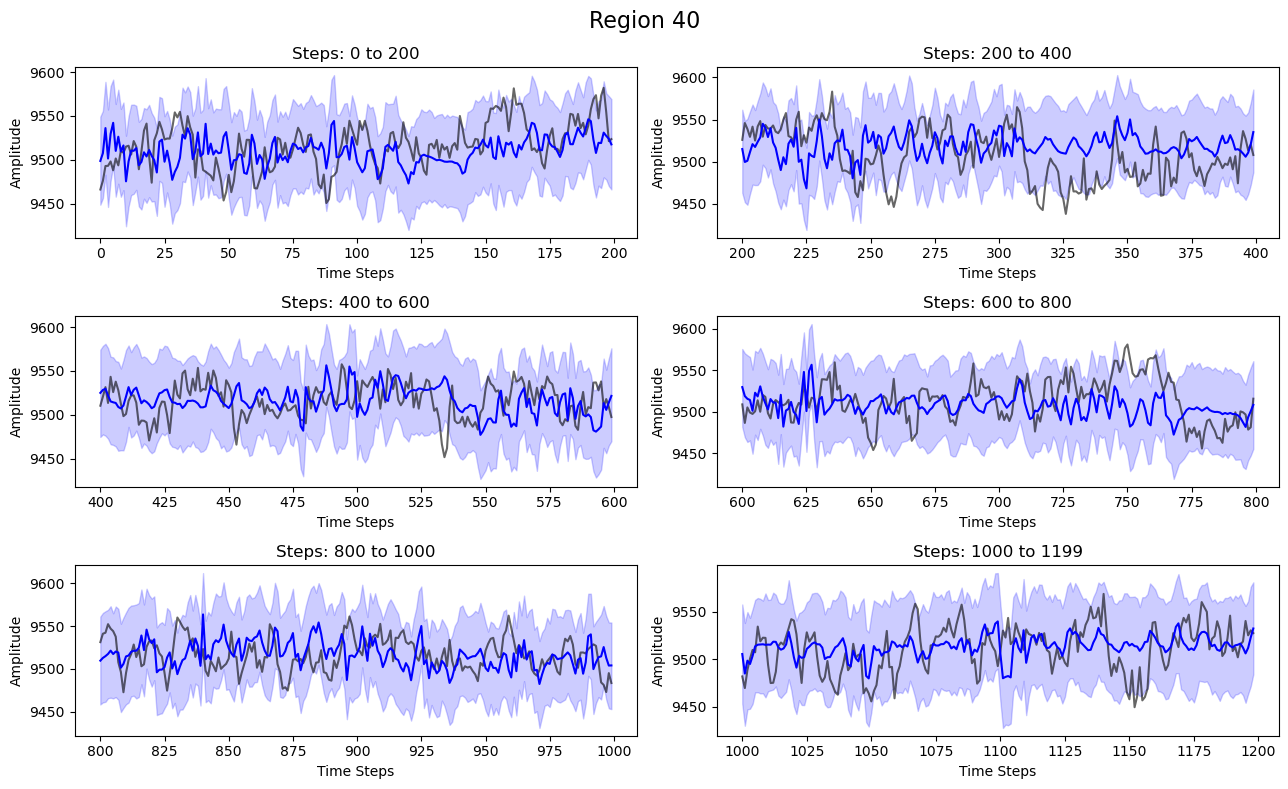

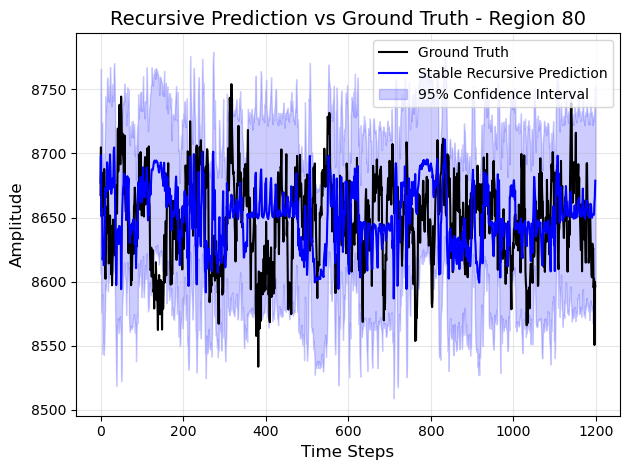

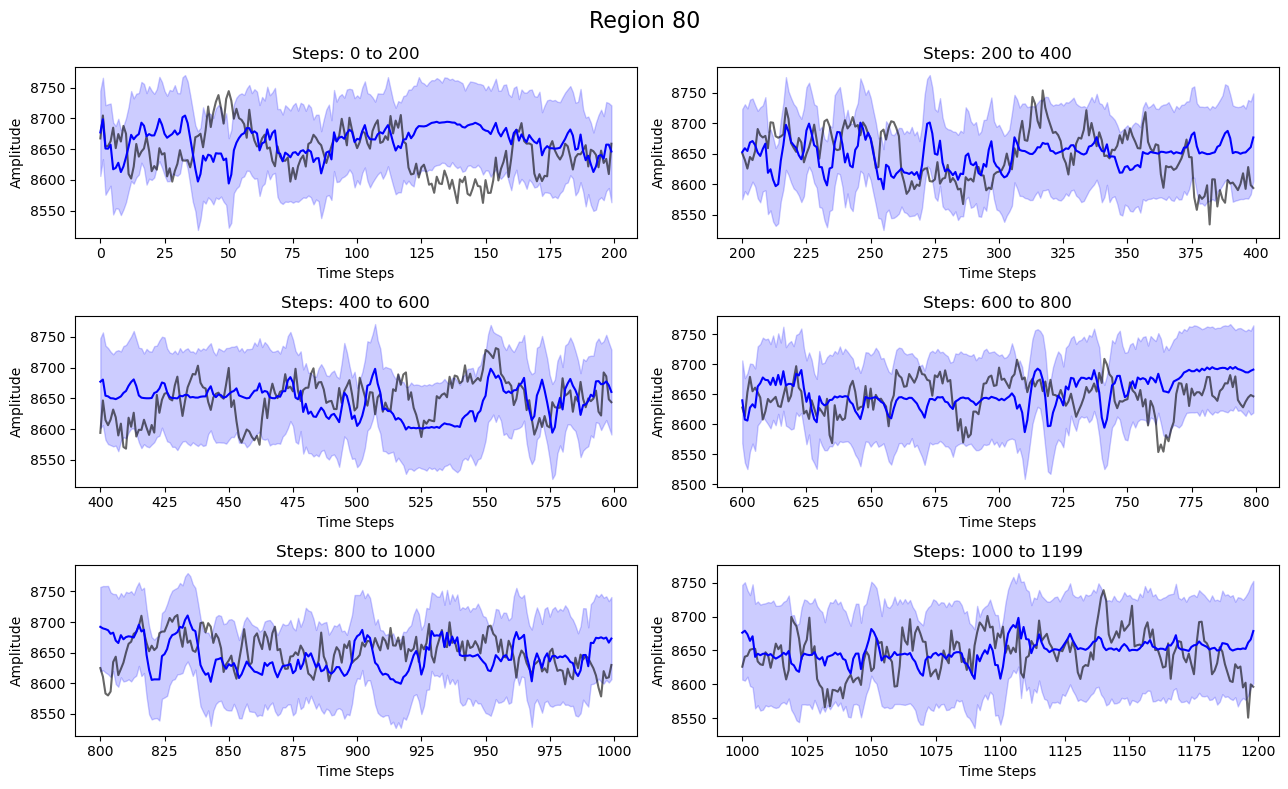

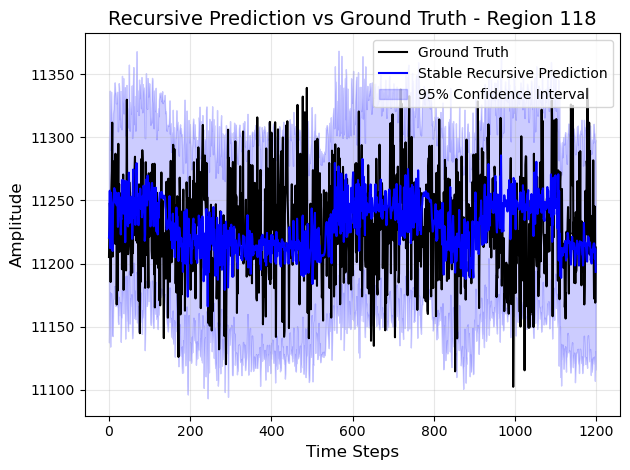

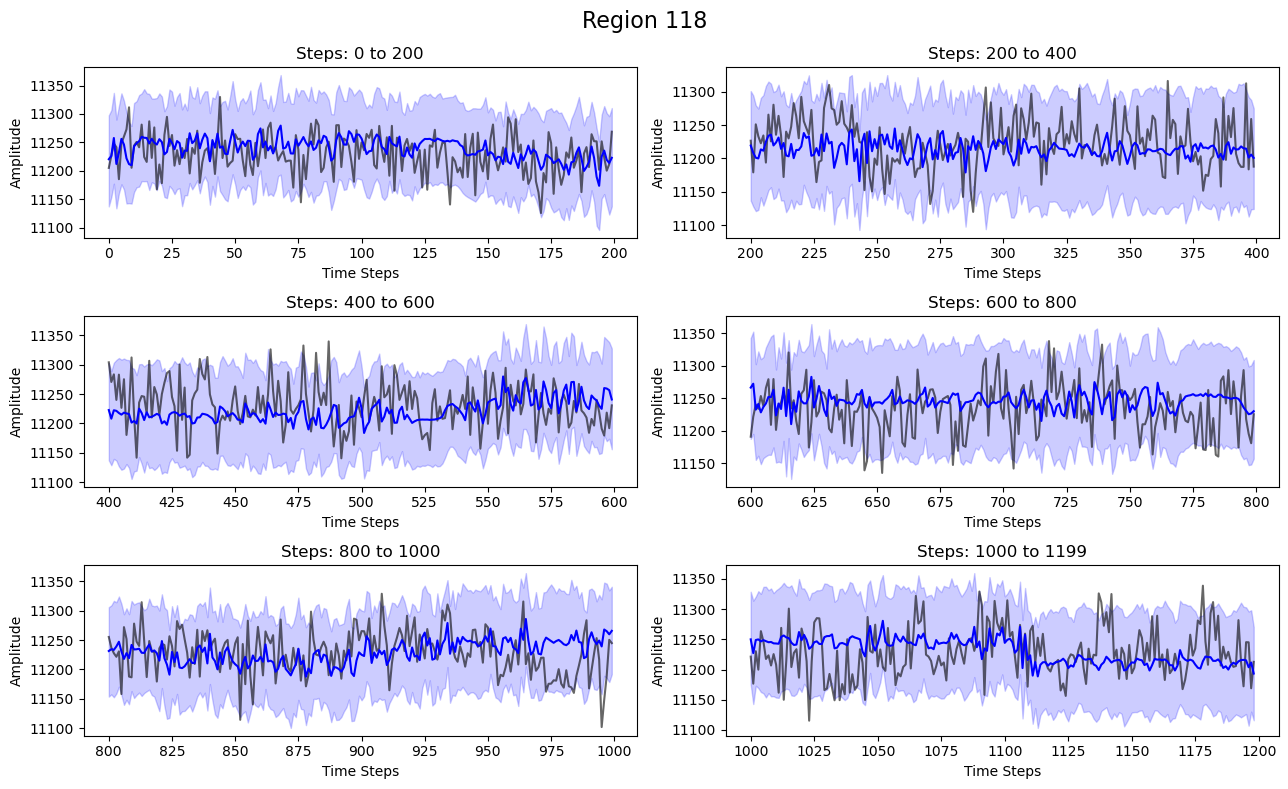

In [34]:
region_idxs = [0,40,80,118]

for region_idx in region_idxs:
    # Plot
    plt.plot(y_true_abs[:, region_idx].cpu(), color='black', label='Ground Truth')
    plt.plot(y_pred_abs[:, region_idx].cpu(), color='blue', label='Stable Recursive Prediction')

    plt.fill_between(
        range(len(y_lower_scaled[:, region_idx])), 
        y_lower_scaled[:, region_idx].cpu(), 
        y_upper_scaled[:, region_idx].cpu(), 
        color='blue', 
        alpha=0.2,
        label='95% Confidence Interval'
    )

    plt.title(f"Recursive Prediction vs Ground Truth - Region {region_idx}", fontsize=14)
    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)

    plt.tight_layout()

    zoomed_plots(region_idx, y_pred_abs, y_true_abs, y_upper_scaled, y_lower_scaled,
                steps = 200, n_plots =6, rows = 3)
    plt.show()

In [35]:
"""
# print metrics results
y_true_abs_scaled = test_ds.predictions.to(y_rec_rescaled.device)
ecov, cal, mcrps = evaluate_metrics(y_samples_scaled, y_true_abs_scaled)
ranges = y_true_abs_scaled.max(dim=0).values - y_true_abs_scaled.min(dim=0).values
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))

print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")
"""

'\n# print metrics results\ny_true_abs_scaled = test_ds.predictions.to(y_rec_rescaled.device)\necov, cal, mcrps = evaluate_metrics(y_samples_scaled, y_true_abs_scaled)\nranges = y_true_abs_scaled.max(dim=0).values - y_true_abs_scaled.min(dim=0).values\nn_mcrps = mcrps / ranges\n\navg_mcrps = n_mcrps.mean().item()\nstd_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))\nstd_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))\nstd_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))\n\nprint(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")\nprint(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")\nprint(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")\n'

## Visualizations

### Heatmap

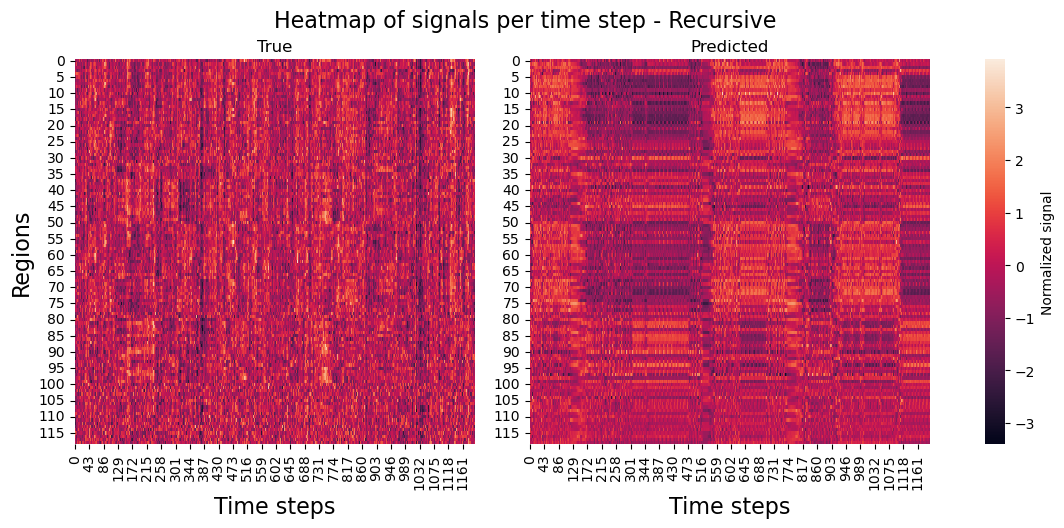

In [39]:
fig, ax = plt.subplots(1,3, figsize = (12,5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle('Heatmap of signals per time step - Recursive', fontsize = 16)

m = test_ds.mean.numpy()
s = test_ds.std.numpy()

y_true_scaled = ((y_true[:,:] - m) / s).T


ax[0].set_title('True')
# Set the labels
sns.heatmap(y_true_scaled, cbar=False, ax=ax[0])
ax[0].set_xlabel("Time steps", fontsize=16)
ax[0].set_ylabel("Regions", fontsize=16)



sns.heatmap(y_rec_rescaled[:,:].T, cbar_kws={'label': 'Normalized signal'}, ax=ax[1], cbar_ax=ax[2])

# Set the labels
ax[1].set_title('Predicted')
ax[1].set_xlabel("Time steps", fontsize=16)
#ax[1].set_ylabel("Regions", fontsize=16)

plt.show()


In [37]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples_scaled, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized avergae
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [38]:
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")

Empirical Coverage: 0.891 ± 0.004
Calibration Error:  0.00316 ± 0.00033
mCRPS (Normalized): 0.1076 ± 0.0015
